In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
df = pd.read_csv('/content/credit_card_fraud_prediction/dataset/creditcard_2023.csv')

In [ ]:
df.head()

Features do nosso dataset possui seguintes descrições:
id: Identificador único de cada transação
V1-V28: Features anonimizadas representando vários atributos de transação (e.g., hora, local, etc.)
Amount: Quantia da transação
Class: Label binário indicando se a transação é fraudulenta (1) ou não (0)

### Primeiramente, limpar os dados retirando informações com "NA" e ajustando variáveis de treinamento e teste

In [ ]:
df_new = df.dropna()

In [ ]:
df_new = df_new.drop(columns=['id'])

In [ ]:
df_new.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0.0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0.0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0.0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0.0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0.0


### Agora separar as features do target

In [ ]:
X = df_new.drop(columns=['Class'])
y = df_new['Class']




### separando treino, validação e teste:




In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

### Posteriormente, normalizamos os valores de Amount

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Aqui uma diferença bem interessante de Autoencoders para Regressão Logística vem do fato de filtrar o treino usando somente as transações **normais**.

In [ ]:
X_train_normal = X_train_scaled[y_train == 0]
X_val_normal = X_val_scaled[y_val == 0]

In [ ]:
input_dim = X_train_normal.shape[1]

# Definindo o modelo
autoencoder = keras.Sequential([
    # Encoder
    layers.Dense(32, activation="relu", input_shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),

    # Decoder
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │           957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269 (12.77 KB)

 Trainable params: 3,269 (12.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_normal, X_val_normal),
    shuffle=True
)

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9416 - val_loss: 0.8402
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8315 - val_loss: 0.7338
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7389 - val_loss: 0.6617
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6756 - val_loss: 0.6081
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6196 - val_loss: 0.5677
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5741 - val_loss: 0.5232
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5404 - val_loss: 0.4986
Epoch 8/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5152 - val_loss: 0.4769
Epoch 9/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4949 - val_loss: 0.4595
Epoch 10/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4789 - val_loss: 0.4465
Epoch 11/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4657 - val_loss: 0.4374
Epoch 12/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4549 - val_lo

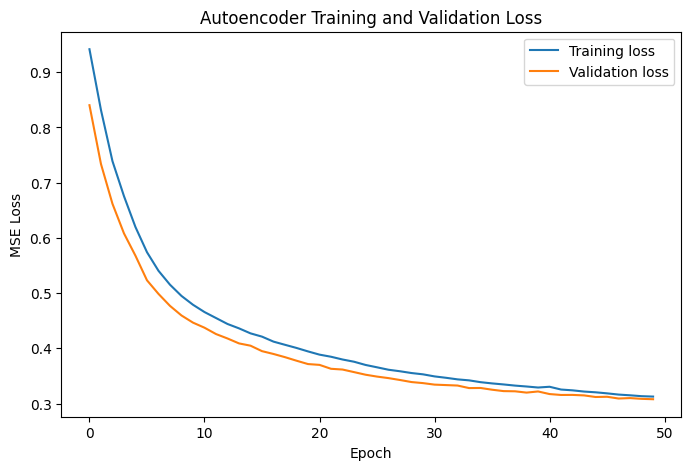

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

### Próxima etapa é fazer o cálculo de errp de reconstrução

In [ ]:
import numpy as np

X_val_pred = autoencoder.predict(X_val_scaled)

reconstruction_error_val = np.mean(
    np.square(X_val_scaled - X_val_pred),
    axis=1
)

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### Definição de threshold. Aqui, utilizaremos 99%

In [ ]:
reconstruction_error_val_normal = reconstruction_error_val[y_val == 0]

threshold = np.percentile(reconstruction_error_val_normal, 99)

print("Threshold:", threshold)

Threshold: 1.554081391138906


In [ ]:
X_test_pred = autoencoder.predict(X_test_scaled)

reconstruction_error_test = np.mean(
    np.square(X_test_scaled - X_test_pred),
    axis=1
)

y_test_pred = (reconstruction_error_test > threshold).astype(int)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

[[4073   49]
 [   3   11]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      4122
         1.0       0.18      0.79      0.30        14

    accuracy                           0.99      4136
   macro avg       0.59      0.89      0.65      4136
weighted avg       1.00      0.99      0.99      4136



In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, reconstruction_error_test)
pr_auc = average_precision_score(y_test, reconstruction_error_test)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9285367713315312
PR-AUC: 0.18552125655562632


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error_test[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(reconstruction_error_test[y_test == 1], bins=50, alpha=0.6, label="Fraud")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

percentiles = [95, 97, 98, 99, 99.2, 99.5, 99.7, 99.8, 99.9]

results = []

for p in percentiles:
    threshold = np.percentile(reconstruction_error_val[y_val == 0], p)

    y_pred_temp = (reconstruction_error_test > threshold).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    results.append({
        "percentile": p,
        "threshold": threshold,
        "precision_fraud": precision,
        "recall_fraud": recall,
        "f1_fraud": f1,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

threshold_results = pd.DataFrame(results)
threshold_results

,percentile,threshold,precision_fraud,recall_fraud,f1_fraud,true_negatives,false_positives,false_negatives,true_positives
0,95.0,0.735277,0.047970,0.928571,0.091228,3864,258,1,13
1,97.0,0.932011,0.078947,0.857143,0.144578,3982,140,2,12
2,98.0,1.123911,0.110092,0.857143,0.195122,4025,97,2,12
3,99.0,1.554081,0.183333,0.785714,0.297297,4073,49,3,11
4,99.2,1.713121,0.215686,0.785714,0.338462,4082,40,3,11
5,99.5,2.253101,0.257143,0.642857,0.367347,4096,26,5,9
6,99.7,2.979158,0.217391,0.357143,0.270270,4104,18,9,5
7,99.8,3.251594,0.157895,0.214286,0.181818,4106,16,11,3
8,99.9,7.977762,0.000000,0.000000,0.000000,4115,7,14,0
